# Ablation Diagnostics Dashboard

This notebook reads outputs produced by:
- `scripts/run_experiment.py`
- `scripts/run_ablation.py`

It visualizes the summary table and loads per-run diagnostics (`reconstruction_maps.png` and `latent_feature_maps.png`) for side-by-side comparison.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

RUNS_ROOT = Path('/g/data/v46/txs156/OM2-emulator/runs').resolve()
SUMMARY_PATH = RUNS_ROOT / 'summary.csv'

print(f'Runs root: {RUNS_ROOT}')
print(f'Summary path: {SUMMARY_PATH}')

Runs root: /g/data/v46/txs156/OM2-emulator/runs
Summary path: /g/data/v46/txs156/OM2-emulator/runs/summary.csv


ModuleNotFoundError: No module named 'einops'

In [5]:
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f'No summary table found at {SUMMARY_PATH}. Run an experiment or ablation first.'
    )

summary = pd.read_csv(SUMMARY_PATH)
metric_columns = [col for col in summary.columns if col.startswith('rmse_')]

print('Available RMSE metrics:', metric_columns)
summary.tail(12)

Available RMSE metrics: ['rmse_OHC', 'rmse_HeatFlux']


,run_name,run_dir,device,final_epoch_loss,total_steps,rmse_OHC,rmse_HeatFlux
0,smoke_baseline,/g/data/v46/txs156/OM2-emulator/runs/smoke_bas...,cpu,1.659439,3,1.821583e+12,108.760828


In [6]:
# Choose the metric you want to rank by.
metric_key = 'rmse_HeatFlux' if 'rmse_HeatFlux' in metric_columns else metric_columns[0]

ranked = summary.sort_values(metric_key, ascending=True).reset_index(drop=True)
display_cols = ['run_name', metric_key, 'final_epoch_loss', 'run_dir']
display_cols = [c for c in display_cols if c in ranked.columns]

ranked[display_cols].head(15)

,run_name,rmse_HeatFlux,final_epoch_loss,run_dir
0,smoke_baseline,108.760828,1.659439,/g/data/v46/txs156/OM2-emulator/runs/smoke_bas...


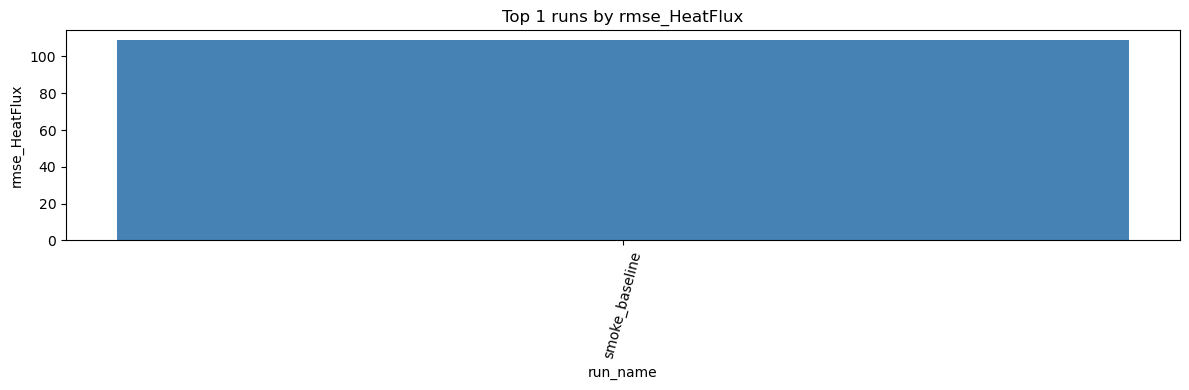

In [7]:
top_n = min(12, len(ranked))
plot_df = ranked.head(top_n)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_df['run_name'], plot_df[metric_key], color='steelblue')
ax.set_title(f'Top {top_n} runs by {metric_key}')
ax.set_ylabel(metric_key)
ax.set_xlabel('run_name')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

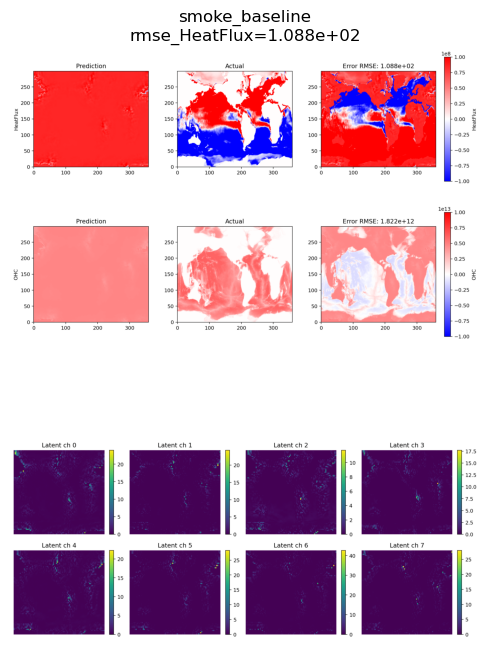

In [8]:
def plot_diagnostic_panels(ranked_df: pd.DataFrame, metric: str, n_runs: int = 4):
    """Plot reconstruction + latent diagnostic images for the top N runs.

    Parameters
    ----------
    ranked_df : pd.DataFrame
        Summary table sorted by the chosen metric.
    metric : str
        Metric column used for ranking display.
    n_runs : int
        Number of top runs to render.
    """
    subset = ranked_df.head(min(n_runs, len(ranked_df)))
    if subset.empty:
        print('No runs available to plot.')
        return

    fig, axes = plt.subplots(2, len(subset), figsize=(5 * len(subset), 8))
    if len(subset) == 1:
        axes = np.array(axes).reshape(2, 1)

    for idx, row in enumerate(subset.itertuples(index=False)):
        run_dir = Path(row.run_dir)
        recon_path = run_dir / 'diagnostics' / 'reconstruction_maps.png'
        latent_path = run_dir / 'diagnostics' / 'latent_feature_maps.png'

        recon_ax = axes[0, idx]
        latent_ax = axes[1, idx]

        if recon_path.exists():
            recon_ax.imshow(mpimg.imread(recon_path))
        else:
            recon_ax.text(0.5, 0.5, 'Missing reconstruction image', ha='center', va='center')
        recon_ax.set_title(f"{row.run_name}\n{metric}={getattr(row, metric):.3e}")
        recon_ax.axis('off')

        if latent_path.exists():
            latent_ax.imshow(mpimg.imread(latent_path))
        else:
            latent_ax.text(0.5, 0.5, 'Missing latent image', ha='center', va='center')
        latent_ax.axis('off')

    plt.tight_layout()
    plt.show()


plot_diagnostic_panels(ranked, metric_key, n_runs=4)